CPU cores: 2
Running from T=1 to T=4

Press ENTER to start T=1 (open Task Manager)...
Running with 1 processes...
Time taken: 1.26 minutes

Press ENTER to start T=2 (open Task Manager)...
Running with 2 processes...
Time taken: 1.13 minutes

Press ENTER to start T=3 (open Task Manager)...
Running with 3 processes...
Time taken: 1.08 minutes

Press ENTER to start T=4 (open Task Manager)...
Running with 4 processes...
Time taken: 1.12 minutes

Final Results:
T=1 -> 1.26 min
T=2 -> 1.13 min
T=3 -> 1.08 min
T=4 -> 1.12 min


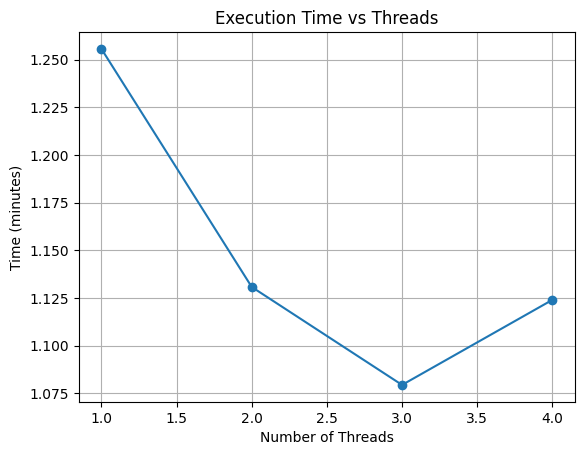

In [1]:
import numpy as np
import time
import multiprocessing as mp
import matplotlib.pyplot as plt

MATRIX_SIZE = 1000
NUM_MATRICES = 500

# constant matrix
constant_matrix = np.random.rand(MATRIX_SIZE, MATRIX_SIZE)


def multiply_matrix(_):
    mat = np.random.rand(MATRIX_SIZE, MATRIX_SIZE)
    result = np.dot(mat, constant_matrix)
    return result


def run_test(processes):
    start = time.time()

    with mp.Pool(processes=processes) as pool:
        pool.map(multiply_matrix, range(NUM_MATRICES))

    end = time.time()
    return (end - start) / 60


if __name__ == "__main__":
    cores = mp.cpu_count()
    max_threads = cores * 2

    print(f"CPU cores: {cores}")
    print(f"Running from T=1 to T={max_threads}")

    thread_list = list(range(1, max_threads + 1))
    times = []

    for t in thread_list:
        input(f"\nPress ENTER to start T={t} (open Task Manager)...")

        print(f"Running with {t} processes...")
        t_time = run_test(t)
        times.append(t_time)

        print(f"Time taken: {t_time:.2f} minutes")

    # ---- PRINT TABLE ----
    print("\nFinal Results:")
    for t, tm in zip(thread_list, times):
        print(f"T={t} -> {tm:.2f} min")

    # ---- GRAPH ----
    plt.plot(thread_list, times, marker='o')
    plt.xlabel("Number of Threads")
    plt.ylabel("Time (minutes)")
    plt.title("Execution Time vs Threads")
    plt.grid(True)
    plt.show()